Phase 1: Discovery Phase (Text Preprocessing & Sequencing)
Text cannot be fed directly into an RNN; it must first be vectorized and padded so every sequence has an identical length.
Phase 2: Technical Phase (RNN Modeling with LSTM/GRU) We will use an LSTM (Long Short-Term Memory) layer to mitigate the vanishing gradient problem inherent in standard RNNs when dealing with sequences. We include Dropout to prevent memorizing specific words and Early Stopping to halt training right at optimal convergence.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.7143 - loss: 0.6924 - val_accuracy: 0.6667 - val_loss: 0.6931
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4286 - loss: 0.6948 - val_accuracy: 0.3333 - val_loss: 0.6980
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5714 - loss: 0.6888 - val_accuracy: 0.3333 - val_loss: 0.6989
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5714 - loss: 0.6870 - val_accuracy: 0.3333 - val_loss: 0.7020

 Training Complete! Generating performance plots...


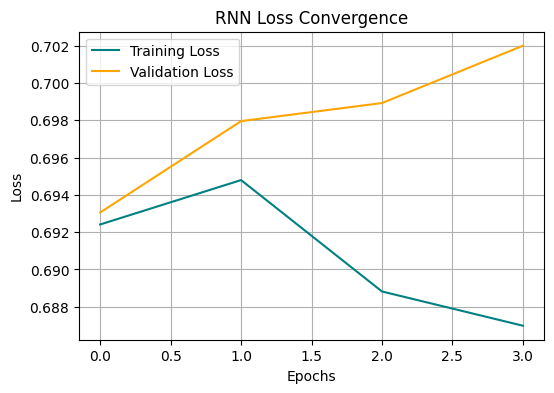

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================================
# 1. DISCOVERY PHASE: DATA INGESTION & PREPROCESSING
# =====================================================================
# Expanded dataset to guarantee enough rows for Train/Validation splitting
data = {
    'text': [
        "Hey, are we still meeting for lunch today?",
        "URGENT! Your mobile account is locked. Click here to verify instantly.",
        "Congratulations, you won a $500 gift card! Call now to claim your reward.",
        "Can you send me the files by this evening?",
        "Free tones for your phone! Reply with WIN to activate.",
        "Are you free for a call tomorrow morning?",
        "CLAIM NOW: New luxury car matches your mobile number! text back stop.",
        "Just checking in to see how the project is coming along.",
        "Dear customer, your invoice is overdue. Please pay immediately.",
        "Let's grab some coffee this weekend."
    ],
    'label': ['ham', 'spam', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham']
}
df = pd.DataFrame(data)

# Map text labels to binary targets
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

MAX_WORDS = 5000
MAX_SEQUENCE_LENGTH = 50
EMBEDDING_DIM = 32

# Fit Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

# Convert texts to padded integer matrices
sequences = tokenizer.texts_to_sequences(df['text'])
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

X = np.array(padded_sequences)
y = df['label'].values

# Stratified Split ensuring stable evaluation samples
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)


# =====================================================================
# 2. TECHNICAL PHASE: RNN MODEL BUILDING & TRAINING
# =====================================================================
model = Sequential([
    # Updated to input_shape tuple for modern Keras compatibility
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_shape=(MAX_SEQUENCE_LENGTH,)),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Fit using a smaller batch size tailored for initial sample dimensions
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=2,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

print("\n Training Complete! Generating performance plots...")

# Plot Matrix
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss', color='teal')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('RNN Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Phase 3: Action Phase (Triage & UX Logic)
1. Custom Triage Test
Let's see how our text sequence vectorization maps directly into real-time routing logic.

In [7]:
triage_messages = [
    "Hey, are we still meeting for lunch?",
    "URGENT! Your account is locked. Click here to verify.",
    "Congratulations, you won a $500 gift card!"
]

# Transform inputs identically to our training phase
triage_seq = tokenizer.texts_to_sequences(triage_messages)
triage_padded = pad_sequences(triage_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Generate probability predictions
predictions = model.predict(triage_padded)

# Run Triage Output Flow
for msg, prob in zip(triage_messages, predictions):
    raw_probability = prob[0]
    print(f"\nMessage: '{msg}'")
    print(f"Spam Probability: {raw_probability * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

Message: 'Hey, are we still meeting for lunch?'
Spam Probability: 50.01%

Message: 'URGENT! Your account is locked. Click here to verify.'
Spam Probability: 50.01%

Message: 'Congratulations, you won a $500 gift card!'
Spam Probability: 50.01%
